In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [13]:
def simulate_loudspeaker(u, fs, params, linear=False):
    Re = params["Re"]
    Le = params["Le"]
    Mms = params["Mms"]
    Rms = params["Rms"]
    Bl0 = params["Bl0"]
    K0 = params["K0"]
    xlim = params["xlim"]
    rtol = params["rtol"]
    atol = params["atol"]

    def Bl(x):
        return Bl0 * np.exp(-(x / xlim)**2)

    def Kms(x):
        xn = x / xlim
        return K0 * (1.0 + 0.4 * xn**2 + 0.05 * xn)

    def u_at(t):
        idx = np.clip(int(t * fs), 0, len(u) - 1)
        return u[idx]

    def ode(t, z):
        i, v, x = z
        voltage = u_at(t)

        di = (voltage - Re * i - Bl(x) * v) / Le
        dv = (Bl(x) * i - Rms * v - Kms(x) * x) / Mms
        dx = v
        return [di, dv, dx]
    
    def lin_ode(t, z):
        i, v, x = z
        voltage = u_at(t)

        di = (voltage - Re * i - Bl0 * v) / Le
        dv = (Bl0 * i - Rms * v - K0 * x) / Mms
        dx = v
        return [di, dv, dx]

    t = np.arange(len(u)) / fs

    if linear:
        ode = lin_ode
    sol = solve_ivp(
        ode,
        t_span=(0, t[-1]),
        y0=[0.0, 0.0, 0.0],
        t_eval=t,
        method="RK45",
        rtol=rtol,
        atol=atol,
    )

    i = sol.y[0]
    v = sol.y[1]
    x = sol.y[2]

    y = v
    return y, {"i": i, "v": v, "x": x}

In [ ]:
import time
class LoudspeakerSim():
    def __init__(self, params):
        self.params = params
        self.Re = params["Re"]
        self.Le = params["Le"]
        self.Mms = params["Mms"]
        self.Rms = params["Rms"]
        self.Bl0 = params["Bl0"]
        self.K0 = params["K0"]
        self.xlim = params["xlim"]
        self.rtol = params["rtol"]
        self.atol = params["atol"]

    def Bl(self, x):
        return self.Bl0 * np.exp(-(x / self.xlim)**2)

    def Kms(self, x):
        xn = x / self.xlim
        return self.K0 * (1.0 + 0.4 * xn**2 + 0.05 * xn)

    def u_at(self, t):
        idx = np.clip(int(t * self.fs), 0, len(self.u) - 1)
        return self.u[idx]

    def ode(self, t, z):
        i, v, x = z
        voltage = self.u_at(t)

        di = (voltage - self.Re * i - self.Bl(x) * v) / self.Le
        dv = (self.Bl(x) * i - self.Rms * v - self.Kms(x) * x) / self.Mms
        dx = v
        return [di, dv, dx]
    
    def lin_ode(self, t, z):
        i, v, x = z
        voltage = self.u_at(t)

        di = (voltage - self.Re * i - self.Bl0 * v) / self.Le
        dv = (self.Bl0 * i - self.Rms * v - self.K0 * x) / self.Mms
        dx = v
        return [di, dv, dx]

    def simulate(self, u, fs):
        self.u = u
        self.fs = fs
        time_start = time.time()
        t = np.arange(len(u)) / self.fs
        sol = solve_ivp(
            self.ode,
            t_span=(0, t[-1]),
            y0=[0.0, 0.0, 0.0],
            t_eval=t,
            method="RK45",
            rtol=self.rtol,
            atol=self.atol,
        )
        self.simtime = time.time() - time_start
        i = sol.y[0]
        v = sol.y[1]
        x = sol.y[2]

        y = x
        return y, {"i": i, "v": v, "x": x}
    
    def simulate_linear(self, u, fs):
        self.u = u
        self.fs = fs
        time_start = time.time()
        t = np.arange(len(u)) / self.fs
        sol = solve_ivp(
            self.lin_ode,


In [ ]:
            t_span=(0, t[-1]),
            y0=[0.0, 0.0, 0.0],
            t_eval=t,
            method="RK45",
            rtol=self.rtol,
            atol=self.atol,
        )
        self.linear_simtime = time.time() - time_start
        i = sol.y[0]
        v = sol.y[1]
        x = sol.y[2]

        y = x
        return y, {"i": i, "v": v, "x": x}


In [28]:
from loudspeaker_sim import LoudspeakerSim

params = {
        "Re": 4.0,
        "Le": 0.1e-3,
        "Mms": 5e-3,
        "Rms": 0.2,
        "K0": 500,
        "Bl0": 2,
        "xlim": 0.01,
        "rtol": 1e-6,
        "atol": 1e-8,
}

speaker = LoudspeakerSim(params)

### Simulating Sine waves

simulation time: linear=17.335s, nonlinear=17.335s


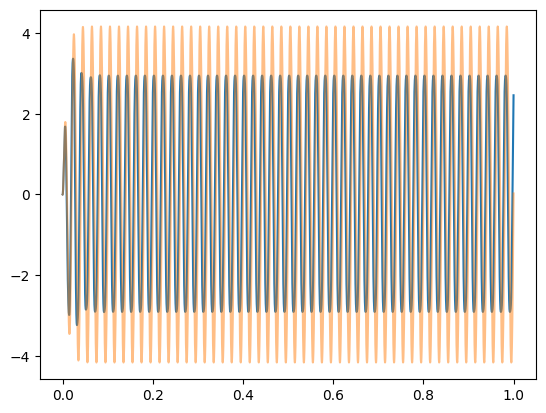

In [29]:
from loudspeaker_sim import LoudspeakerSim
fs = 16000
L = 1
a= 10
freq = 50
x = np.linspace(0, L, fs)
u = a * np.sin(2 * np.pi * freq * x)

y, s = speaker.simulate(u, fs)
y_lin, s_lin = speaker.simulate_linear(u, fs)
print(f"simulation time: linear={speaker.simtime:.3f}s, nonlinear={speaker.simtime:.3f}s")

#plt.plot(x,u)
plt.plot(x,y)
plt.plot(x,y_lin, alpha= 0.5)

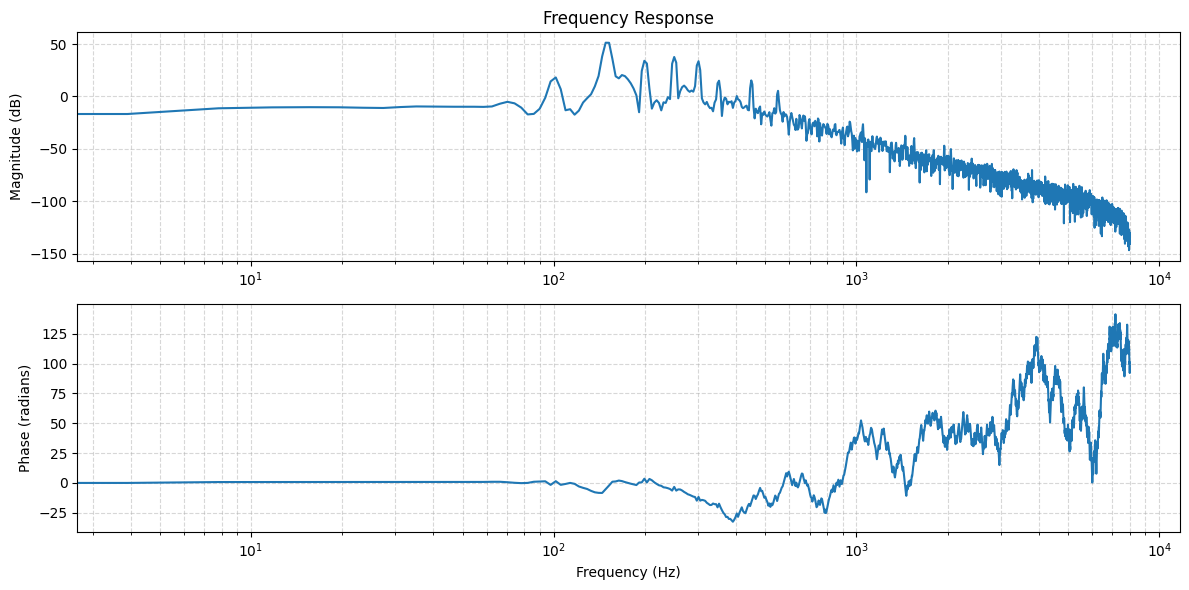

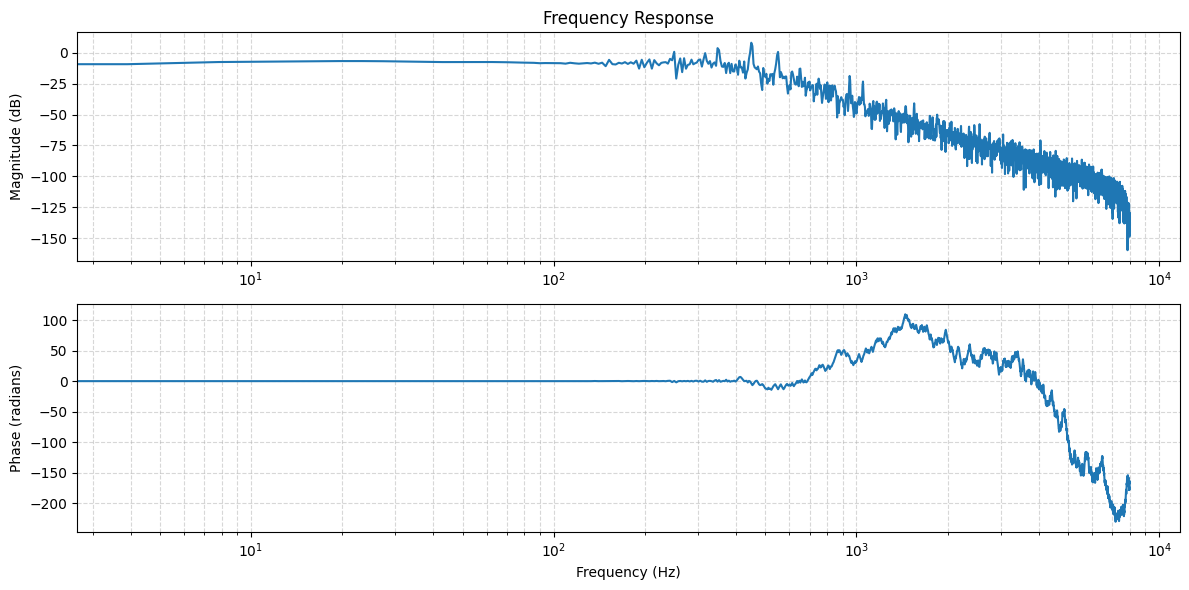

In [27]:
freqs, H, mag_db, phase = estimate_frf_welch(u, y, fs)
plot_frequency_response(freqs, mag_db, phase)
freqs, H, mag_db, phase = estimate_frf_welch(u, y_lin, fs)
plot_frequency_response(freqs, mag_db, phase)

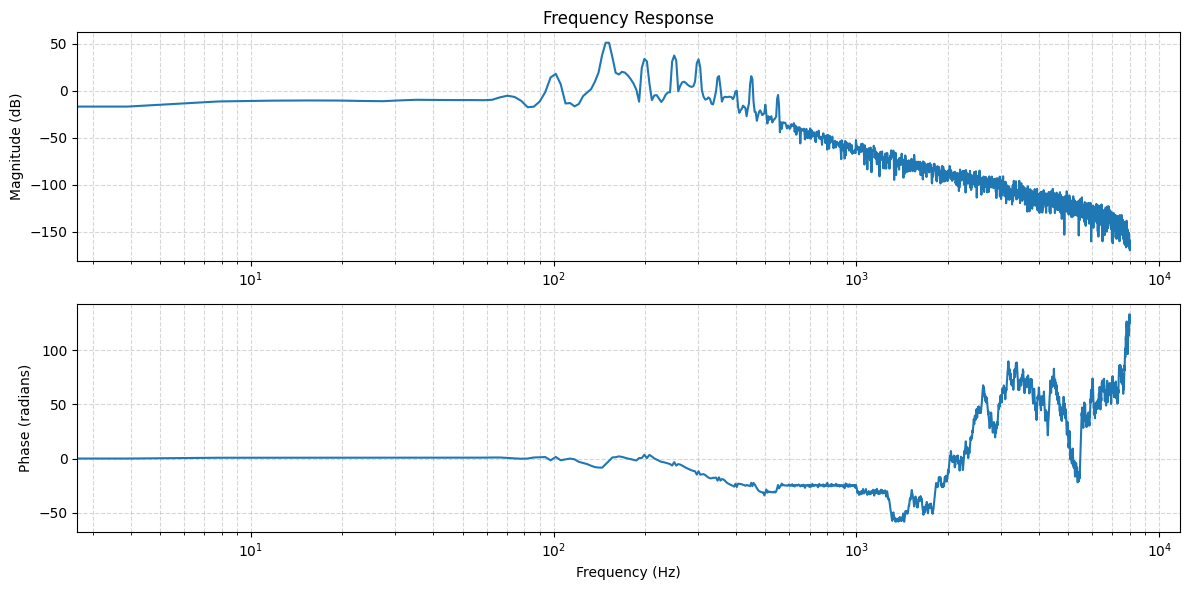

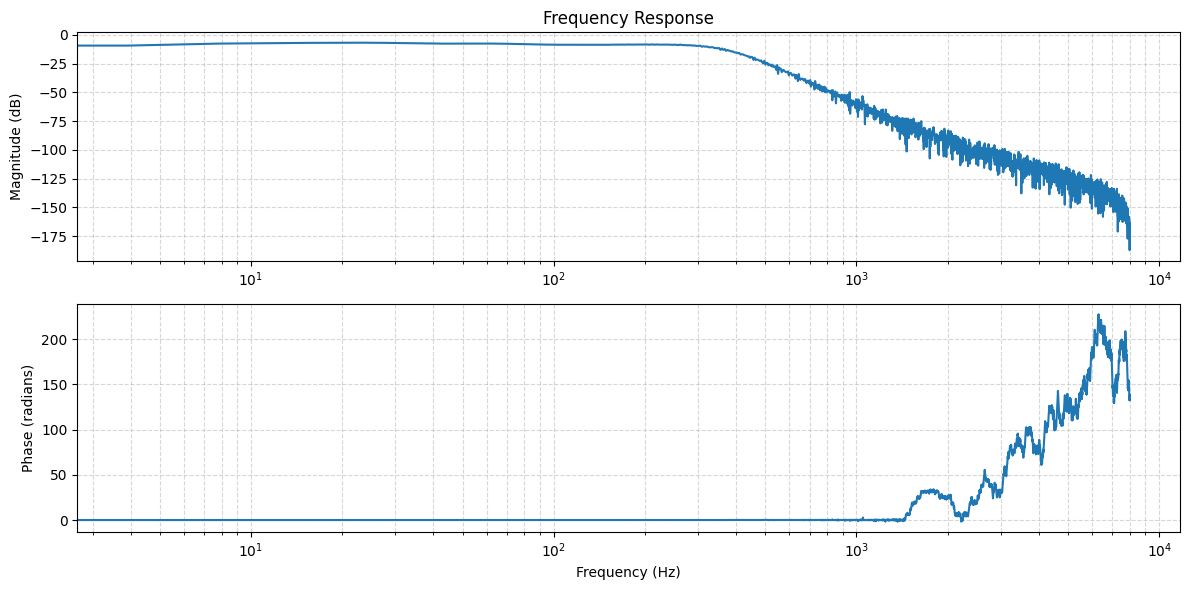

In [30]:
freqs, H, mag_db, phase = estimate_frf_welch(u, y, fs)
plot_frequency_response(freqs, mag_db, phase)
freqs, H, mag_db, phase = estimate_frf_welch(u, y_lin, fs)
plot_frequency_response(freqs, mag_db, phase)

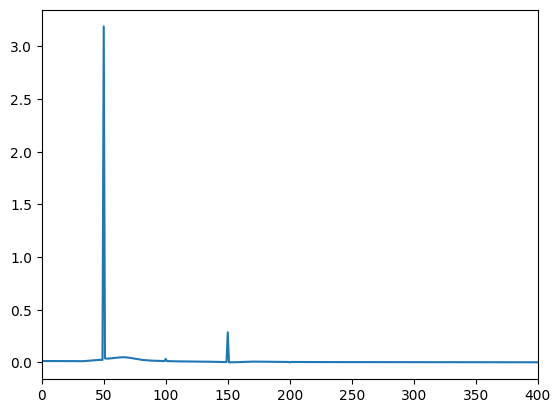

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.fftpack

# Number of samplepoints
N = fs
# sample spacing
T = 1.0 / fs

yf = scipy.fftpack.fft(y)
xf = np.linspace(0.0, 1.0/(2.0*T), N//2)

fig, ax = plt.subplots()
ax.plot(xf, 2.0/N * np.abs(yf[:N//2]))
ax.set_xlim(0, 400)
plt.show()

## Simulating Sweeps

In [36]:
from scipy.signal import chirp 
import plotly.graph_objects as go
fs = 44100
L = 1
x = np.linspace(0, L, fs)
a = 20
f0 = 20
f1 = min(20000, 0.45 * fs)
print(f"Chirp from {f0} Hz to {f1} Hz")
sweep = a * chirp(
    x,
    f0=f0,
    f1=f1,
    t1=L,
    method="logarithmic",)

y, s = speaker.simulate(sweep, fs)
y_lin, s_lin = speaker.simulate_linear(sweep, fs)
print(f"simulation time: linear={speaker.linear_simtime:.3f}s, nonlinear={speaker.simtime:.3f}s")


Chirp from 20 Hz to 19845.0 Hz
simulation time: linear=44.656s, nonlinear=52.548s


In [98]:
f = go.FigureWidget()

#f.add_scatter(y=sweep, name="Input")
f.add_scatter(y=y, name="Non-linear")
f.add_scatter(y=y_lin, name="Linear")
f.add_scatter(y=y-y_lin, name="Residual")


tick_freqs = np.array([f0, 50, 100, 200, 500, 1000, 2000, 5000, 10000, f1])
# Convert those frequencies to sample positions for a log sweep
tick_samples = fs*L * np.log(tick_freqs / f0) / np.log(f1 / f0)

f.update_xaxes(
    tickmode="array",
    tickvals=tick_samples,
    ticktext=[f"{f:g} Hz" if f < 1000 else f"{f/1000:g} kHz" for f in tick_freqs],
    title="Frequency"
)

f.show()

FigureWidget({
    'data': [{'name': 'Non-linear',
              'type': 'scatter',
              'uid': '4b431db7-0c12-41d4-b385-f5eb2f440039',
              'y': {'bdata': ('AAAAAAAAAADOF+vDrt6APqpkH2Xl/6' ... 'Jnd5k+2L4uBaE5pC3Yvre66077Sdi+'),
                    'dtype': 'f8'}},
             {'name': 'Linear',
              'type': 'scatter',
              'uid': '7ecb1d1e-6328-44bd-89e8-a5ee2f40c5ad',
              'y': {'bdata': ('AAAAAAAAAAA41evDrt6APhUrYmXl/6' ... 'qLlCCexD4i+D0r0N7EPtMZ+ZqbvsQ+'),
                    'dtype': 'f8'}},
             {'name': 'Residual',
              'type': 'scatter',
              'uid': 'b9c9bdb8-c227-417f-98d8-4e7e93d668ee',
              'y': {'bdata': ('AAAAAAAAAAAAAAAAQK03vAAAAMCasc' ... 'vW4NRG4b6gAKAnhk7hvtAjNI6kVOG+'),
                    'dtype': 'f8'}}],
    'layout': {'template': '...',
               'xaxis': {'tickmode': 'array',
                         'ticktext': [20 Hz, 50 Hz, 100 Hz, 200 Hz, 500 Hz, 1 kHz,
                    

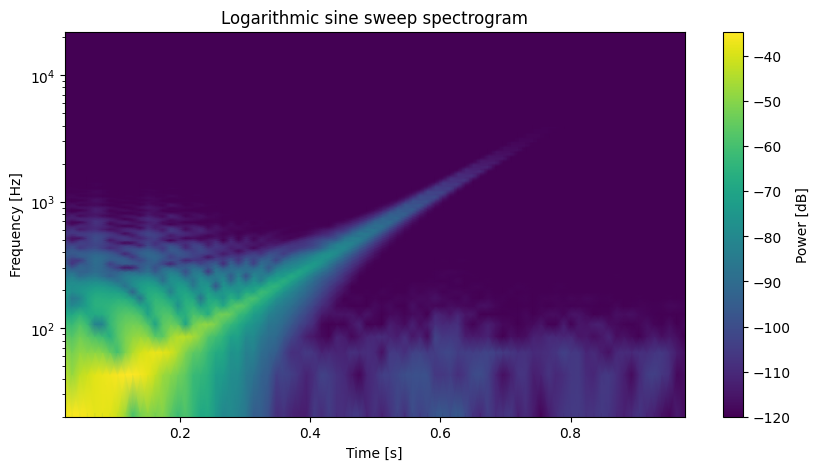

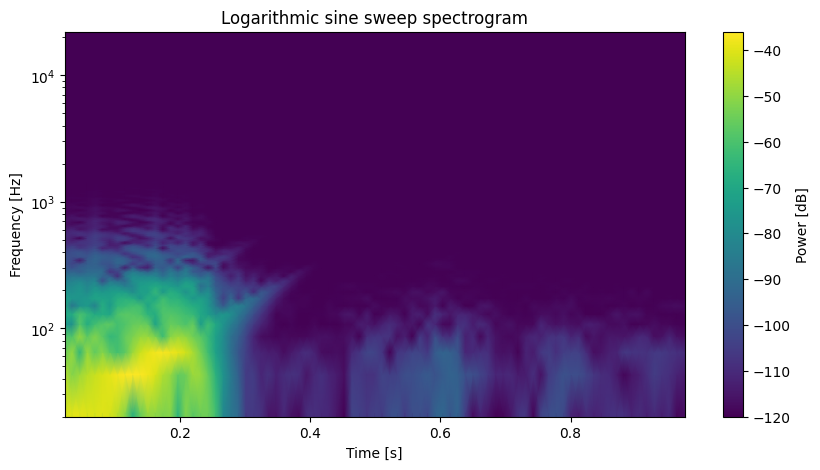

In [102]:
from scipy.signal import spectrogram
# Spectrogram
def plot_spectrogram(signal, fs):
    freqs, times, Sxx = spectrogram(
        signal,
        fs=fs,
        nperseg=2048,
        noverlap=1536,
        scaling="spectrum"
    )

    plt.figure(figsize=(10, 5))
    plt.pcolormesh(times, freqs, 10 * np.log10(Sxx + 1e-12), shading="gouraud")
    plt.yscale("log")
    plt.ylim(f0, fs / 2)
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency [Hz]")
    plt.colorbar(label="Power [dB]")
    plt.title("Logarithmic sine sweep spectrogram")
    plt.show()
plot_spectrogram(y_lin, fs)
plot_spectrogram(y-y_lin, fs)

In [10]:
# Estimate frequency response
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window

def estimate_frequency_response(u, y, fs, n_fft=None):
    u = np.asarray(u)
    y = np.asarray(y)

    N = min(len(u), len(y))
    u = u[:N]
    y = y[:N]

    if n_fft is None:
        n_fft = int(2 ** np.ceil(np.log2(N)))

    window = get_window("hann", N)

    U = np.fft.rfft(u * window, n=n_fft)
    Y = np.fft.rfft(y * window, n=n_fft)

    eps = 1e-12
    H = Y / (U + eps)

    freqs = np.fft.rfftfreq(n_fft, 1 / fs)

    mag_db = 20 * np.log10(np.abs(H) + eps)
    phase = np.unwrap(np.angle(H))

    return freqs, H, mag_db, phase

def plot_frequency_response(freqs, mag_db, phase, y_lim_db=None, x_lim=None):
    plt.figure(figsize=(12, 6))

    plt.subplot(2, 1, 1)
    plt.semilogx(freqs, mag_db)
    plt.title("Frequency Response")
    if y_lim_db:
        plt.ylim(y_lim_db)
    if x_lim:
        plt.xlim(x_lim)

    plt.ylabel("Magnitude (dB)")
    plt.grid(which="both", linestyle="--", alpha=0.5)

    plt.subplot(2, 1, 2)
    plt.semilogx(freqs, phase)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Phase (radians)")
    plt.grid(which="both", linestyle="--", alpha=0.5)
    if x_lim:
        plt.xlim(x_lim)
    plt.tight_layout()
    plt.show()

from scipy.signal import csd, welch

def estimate_frf_welch(u, y, fs, nperseg=4096):
    f, Puy = csd(u, y, fs=fs, nperseg=nperseg)
    f, Puu = welch(u, fs=fs, nperseg=nperseg)

    eps = 1e-12
    H = Puy / (Puu + eps)

    mag_db = 20 * np.log10(np.abs(H) + eps)
    phase = np.unwrap(np.angle(H))

    return f, H, mag_db, phase

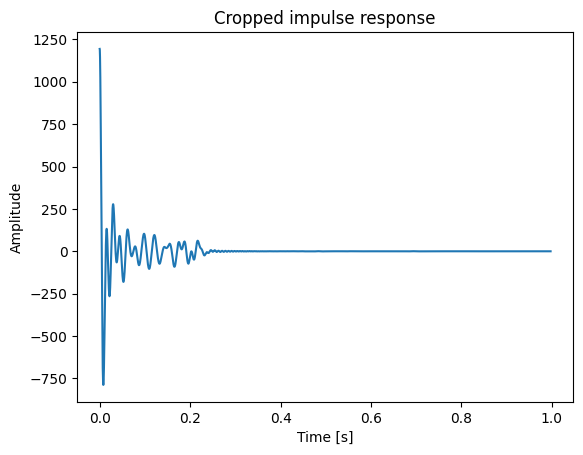

In [ ]:
# Compute impulse response
from scipy.signal import fftconvolve
# Inverse filter for log sweep
# Reverse sweep and apply amplitude compensation
K = 1 / np.log(f1 / f0)
instantaneous_freq = f0 * np.exp(x / K)
envelope = instantaneous_freq / f0

inverse_sweep = sweep[::-1]/ envelope

impulse_response = fftconvolve(y, inverse_sweep, mode="full")

peak = np.argmax(np.abs(impulse_response))

ir_len = int(1.0 * fs)  # keep 1 second
ir = impulse_response[peak : peak + ir_len]

plt.plot(np.arange(len(ir)) / fs, ir)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Cropped impulse response")
plt.show()

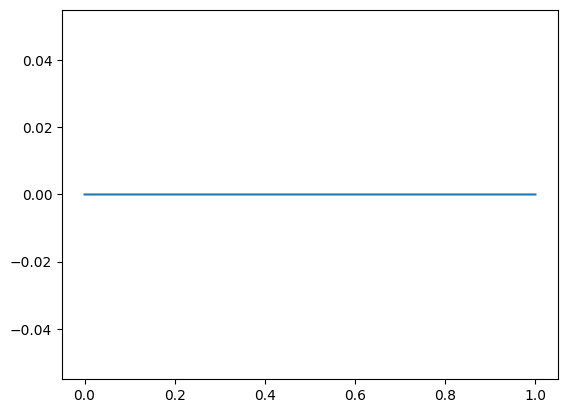

In [5]:
impulse = np.zeros(fs)
impulse[2000] = 1.0

h, states = speaker.simulate_linear(impulse, fs)
plt.plot(x, h)

### Frequency response

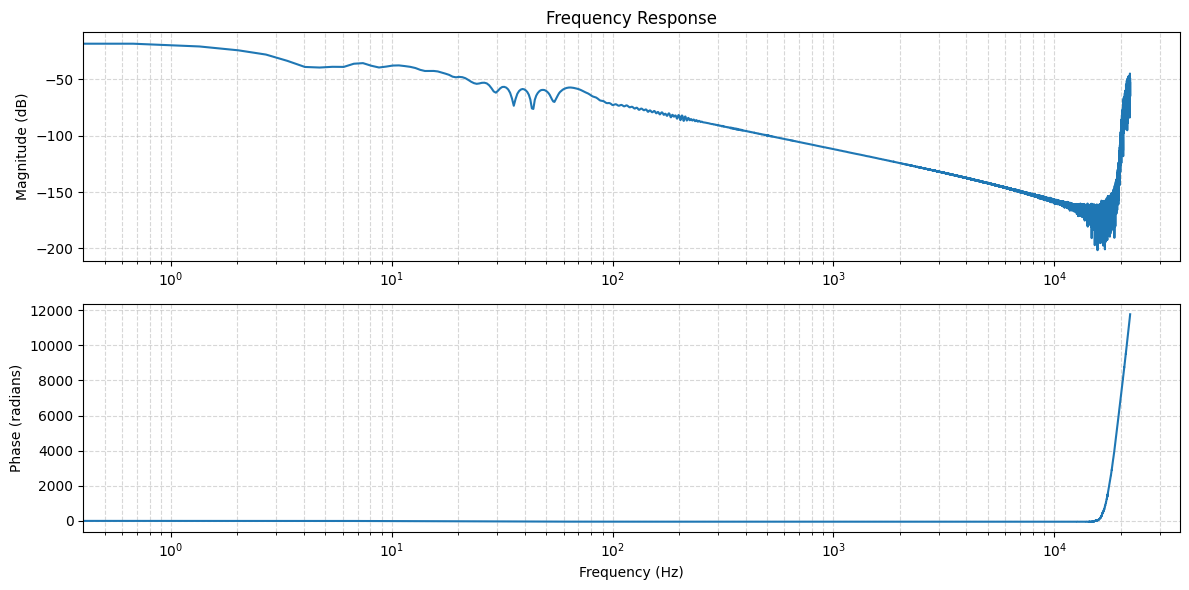

In [106]:
freqs, H, mag_db, phase = estimate_frequency_response(sweep, y, fs)
plot_frequency_response(freqs, mag_db, phase)

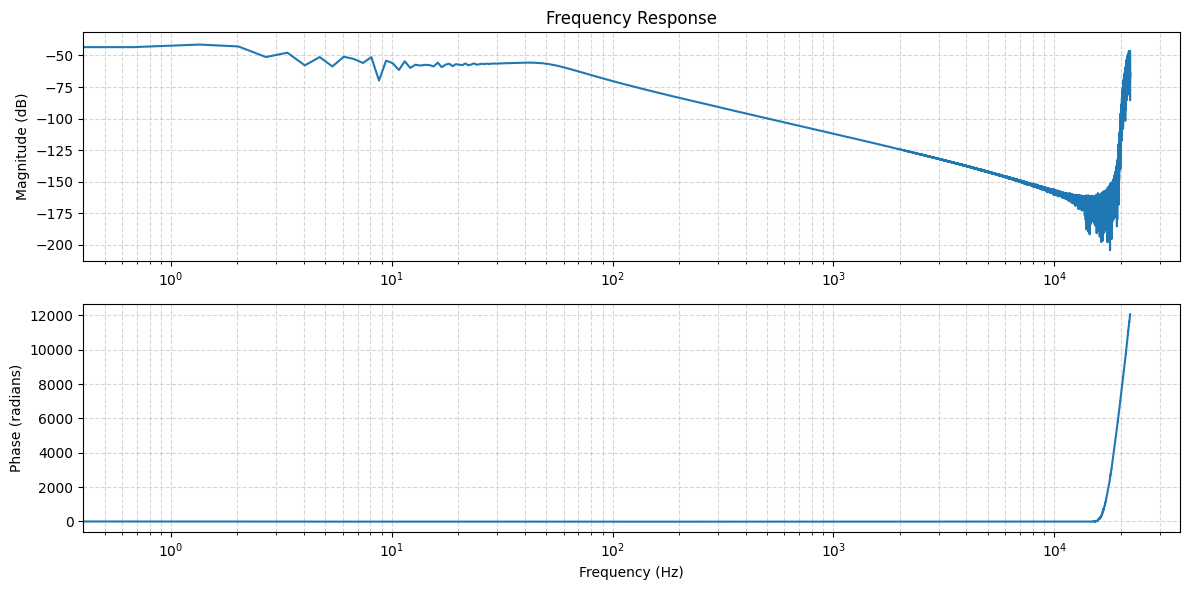

In [107]:
freqs, H, mag_db, phase = estimate_frequency_response(sweep, y_lin, fs)
plot_frequency_response(freqs, mag_db, phase)

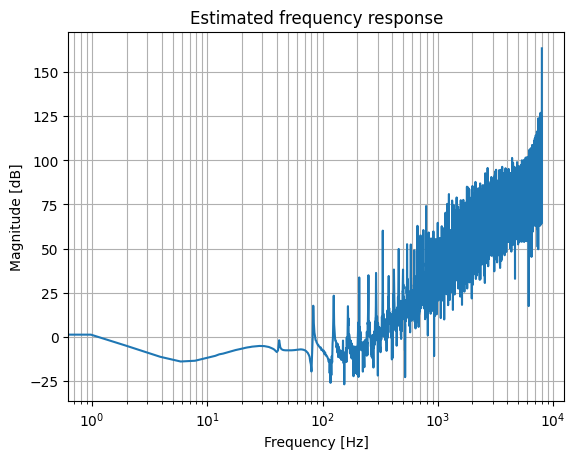

In [32]:
freqs, H, mag_db, phase = estimate_frequency_response(u, y_lin, fs)

plt.figure()
plt.semilogx(freqs, mag_db)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.grid(True, which="both")
plt.title("Estimated frequency response")
plt.show()

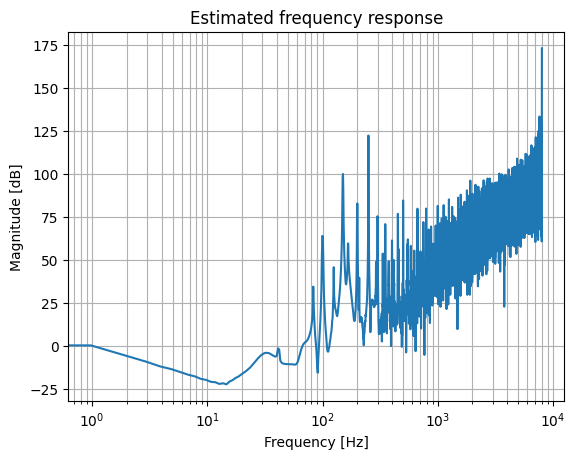

In [34]:
freqs, H, mag_db, phase = estimate_frequency_response(u, y-y_lin, fs)

plt.figure()
plt.semilogx(freqs, mag_db)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.grid(True, which="both")
plt.title("Estimated frequency response")
plt.show()

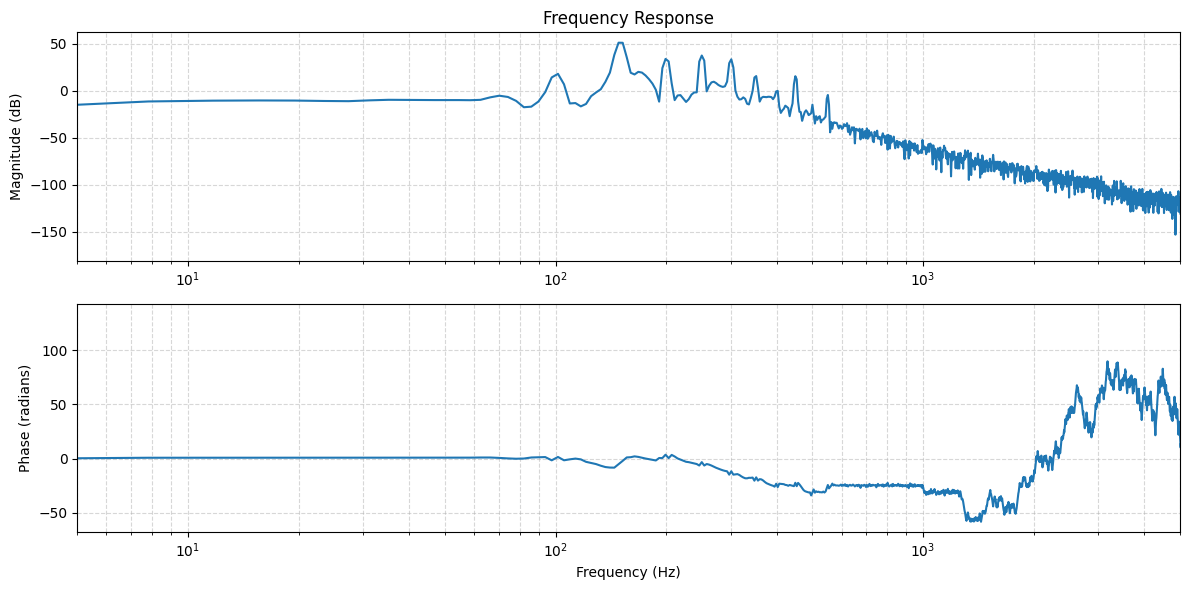

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import csd, welch

def estimate_frf_welch(u, y, fs, nperseg=4096):
    f, Puy = csd(u, y, fs=fs, nperseg=nperseg)
    f, Puu = welch(u, fs=fs, nperseg=nperseg)

    eps = 1e-12
    H = Puy / (Puu + eps)

    mag_db = 20 * np.log10(np.abs(H) + eps)
    phase = np.unwrap(np.angle(H))

    return f, H, mag_db, phase

freqs, H, mag_db, phase = estimate_frf_welch(u, y, fs)

plot_frequency_response(freqs, mag_db, phase, x_lim=[5,5000], )

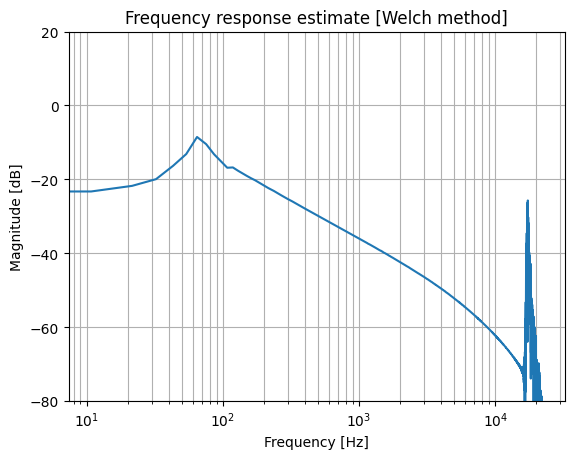

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import csd, welch

def estimate_frf_welch(u, y, fs, nperseg=4096):
    f, Puy = csd(u, y, fs=fs, nperseg=nperseg)
    f, Puu = welch(u, fs=fs, nperseg=nperseg)

    eps = 1e-12
    H = Puy / (Puu + eps)

    mag_db = 20 * np.log10(np.abs(H) + eps)
    phase = np.unwrap(np.angle(H))

    return f, H, mag_db, phase

f, H, mag_db, phase = estimate_frf_welch(sweep, y, fs)

plt.figure()
plt.semilogx(f, mag_db)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.grid(True, which="both")
plt.title("Frequency response estimate [Welch method]")
plt.ylim(-80, 20)
plt.show()

questions:
- Why does the frequency response look so different fft vs welch
- impulse response: different simulated vs computed with inverse sweep deconvolution

### Harmonic Distortion

In [128]:
import numpy as np
from scipy.signal import get_window

def sine_wave(freq, fs, duration, amplitude=1.0):
    t = np.arange(int(duration * fs)) / fs
    return amplitude * np.sin(2 * np.pi * freq * t)

def measure_harmonics_fft(y, fs, f0, n_harmonics=5, discard_seconds=0.2):
    """
    Measures harmonic amplitudes using FFT bin lookup.
    Works best if the sine frequency fits well into the FFT window.
    """
    start = int(discard_seconds * fs)
    y = y[start:]

    N = len(y)
    window = get_window("hann", N)
    yw = y * window

    Y = np.fft.rfft(yw)
    freqs = np.fft.rfftfreq(N, 1 / fs)

    # Amplitude correction for Hann window
    coherent_gain = np.sum(window) / N

    amps = []

    for k in range(1, n_harmonics + 1):
        fk = k * f0

        if fk >= fs / 2:
            amps.append(np.nan)
            continue

        idx = np.argmin(np.abs(freqs - fk))

        # Single-sided amplitude estimate
        amp = 2 * np.abs(Y[idx]) / (N * coherent_gain)
        amps.append(amp)

    return np.array(amps)


def harmonic_amplitudes_projection(y, fs, f0, n_harmonics=5, discard_seconds=0.2):
    start = int(discard_seconds * fs)
    y = np.asarray(y[start:])
    t = np.arange(len(y)) / fs

    amps = []
    for k in range(1, n_harmonics + 1):
        fk = k * f0
        if fk >= fs / 2:
            amps.append(np.nan)
            continue

        basis = np.column_stack([
            np.sin(2 * np.pi * fk * t),
            np.cos(2 * np.pi * fk * t),
        ])
        coeffs, *_ = np.linalg.lstsq(basis, y, rcond=None)
        amps.append(np.sqrt(coeffs[0]**2 + coeffs[1]**2))

    return np.array(amps)


def thd_from_harmonics(amps):
    A1 = amps[0]
    harmonics = amps[1:]

    harmonics = harmonics[~np.isnan(harmonics)]

    if A1 <= 1e-12:
        return np.nan

    thd = np.sqrt(np.sum(harmonics ** 2)) / A1
    return thd

In [131]:
fs = 16000
f0 = 50
amp = 10.0

u = sine_wave(f0, fs, duration=1.0, amplitude=amp)
y, states = speaker.simulate(u, fs)

harmonic_amps = harmonic_amplitudes_projection(y, fs, f0, n_harmonics=5)
thd = thd_from_harmonics(harmonic_amps)

print("Harmonics:", harmonic_amps)
print("THD [%]:", 100 * thd)
print("THD [dB]:", 20 * np.log10(thd + 1e-12))

Harmonics: [1.02146425e-02 6.69188438e-05 3.01707040e-04 4.68229698e-06
 4.24409743e-06]
THD [%]: 3.026086099459663
THD [dB]: -30.382374387911


Amp: 1.12, THD [%]: 0.01, THD [dB]: -82.95
Amp: 1.41, THD [%]: 0.01, THD [dB]: -80.73
Amp: 1.78, THD [%]: 0.01, THD [dB]: -78.17
Amp: 2.24, THD [%]: 0.02, THD [dB]: -75.91
Amp: 2.82, THD [%]: 0.02, THD [dB]: -73.08
Amp: 3.55, THD [%]: 0.03, THD [dB]: -70.25
Amp: 4.47, THD [%]: 0.04, THD [dB]: -67.36
Amp: 5.62, THD [%]: 0.07, THD [dB]: -63.71
Amp: 7.08, THD [%]: 0.10, THD [dB]: -60.26
Amp: 8.91, THD [%]: 0.15, THD [dB]: -56.69


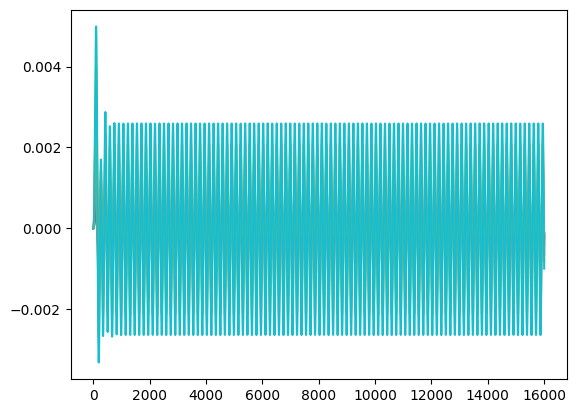

In [132]:
f0 = 100
amps_db = np.arange(1, 20, 2)
amps = 10 ** (amps_db / 20)
all_harmonic_amps = []
plt.figure()
for amp in amps:
    u = sine_wave(f0, fs, duration=1.0, amplitude=amp)
    y, states = speaker.simulate(u, fs)

    harmonic_amps = harmonic_amplitudes_projection(y, fs, f0, n_harmonics=5)
    thd = thd_from_harmonics(harmonic_amps)
    all_harmonic_amps.append(harmonic_amps)

    print(f"Amp: {amp:.2f}, THD [%]: {100 * thd:.2f}, THD [dB]: {20 * np.log10(thd + 1e-12):.2f}")
    plt.plot(y, label=f"Amp={amp:.2f}")

In [133]:
amp = 8.91
frequencies = np.arange(20, 201, 20)
all_harmonic_amps = []
all_thds = []
y_sims = []
for f0 in frequencies:
    u = sine_wave(f0, fs, duration=1.0, amplitude=amp)
    y, states = speaker.simulate(u, fs)

    harmonic_amps = measure_harmonics_fft(y, fs, f0, n_harmonics=5)
    thd = thd_from_harmonics(harmonic_amps)
    all_harmonic_amps.append(harmonic_amps)
    all_thds.append(thd)
    y_sims.append(y)
    print(f"f0: {f0}, THD [%]: {100 * thd:.2f}, THD [dB]: {20 * np.log10(thd + 1e-12):.2f}")

f0: 20, THD [%]: 21.05, THD [dB]: -13.53
f0: 40, THD [%]: 4.42, THD [dB]: -27.09
f0: 60, THD [%]: 1.00, THD [dB]: -40.02
f0: 80, THD [%]: 0.31, THD [dB]: -50.06
f0: 100, THD [%]: 0.15, THD [dB]: -56.69
f0: 120, THD [%]: 0.07, THD [dB]: -62.53
f0: 140, THD [%]: 0.04, THD [dB]: -67.71
f0: 160, THD [%]: 0.03, THD [dB]: -70.57
f0: 180, THD [%]: 0.02, THD [dB]: -75.90
f0: 200, THD [%]: 0.01, THD [dB]: -79.59


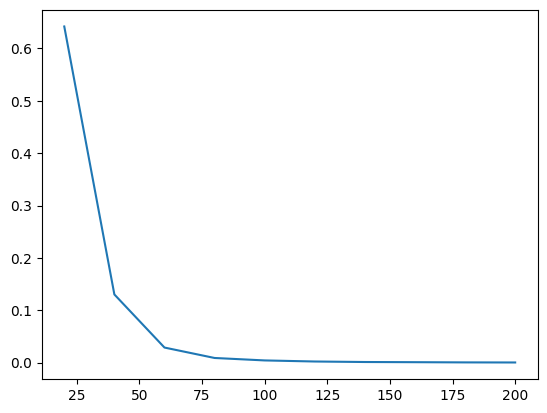

In [88]:
plt.plot(frequencies, all_thds)

In [17]:
"""
Measures harmonic amplitudes using FFT bin lookup.
Works best if the sine frequency fits well into the FFT window.
"""

start = int(0.2 * fs)
y = y[start:]

N = len(y)
window = get_window("hann", N)
yw = y * window

Y = np.fft.rfft(yw)
freqs = np.fft.rfftfreq(N, 1 / fs)

# Amplitude correction for Hann window
coherent_gain = np.sum(window) / N

amps = []

for k in range(1, 5 + 1):
    fk = k * f0

    if fk >= fs / 2:
        amps.append(np.nan)
        continue

    idx = np.argmin(np.abs(freqs - fk))

    # Single-sided amplitude estimate
    amp = 2 * np.abs(Y[idx]) / (N * coherent_gain)
    amps.append(amp)